In [1]:
!pip install -q diffusers transformers accelerate huggingface_hub opencv-python-headless pillow kagglehub gradio voluptuous

In [2]:
!pip install --upgrade diffusers transformers accelerate

  Using cached diffusers-0.39.0-py3-none-any.whl.metadata (20 kB)
Using cached diffusers-0.39.0-py3-none-any.whl (5.6 MB)
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.29.2
    Uninstalling diffusers-0.29.2:
      Successfully uninstalled diffusers-0.29.2


Étape 1 — Configuration des paramètres et du matériel


In [3]:
import torch
from pathlib import Path

# Répertoire de travail Colab
WORKDIR = Path("/content/work").resolve()
WORKDIR.mkdir(parents=True, exist_ok=True)
print(f"Working directory: {WORKDIR}")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Detected device: {DEVICE}")

if DEVICE == "cuda":
    CFG = dict(
        target_count=15,        # Réduit de 45 à 15 images
        min_side=400,
        resolution=512,
        repeats=10,             # Réduit de 20 à 10
        max_train_steps=300,    # Réduit de 1500 à 300 steps pour un entraînement rapide (~5-10 min)
        network_dim=16,         # Réduit de 32 à 16 (LoRA plus léger)
        network_alpha=8,
        mixed_precision="fp16",
        infer_steps=25,
    )
    print("✅ GPU détecté — Configuration Colab optimisée (rapide).")
else:
    CFG = dict(
        target_count=5, min_side=200, resolution=256, repeats=2,
        max_train_steps=20, network_dim=4, network_alpha=2,
        mixed_precision="no", infer_steps=10,
    )
    print("⚠️ Aucun GPU détecté ! Allez dans 'Exécution' -> 'Modifier le type d'exécution' -> Choisissez 'T4 GPU'.")

Working directory: /content/work
Detected device: cuda
✅ GPU détecté — Configuration Colab optimisée (rapide).


Étape 2 — Téléchargement et filtrage du jeu de données

In [4]:
import os, random, cv2
from pathlib import Path
from PIL import Image

LOCAL_INPUT_PATH = "/content/tennis-player-actions-dataset"

if os.path.isdir(LOCAL_INPUT_PATH) and os.listdir(LOCAL_INPUT_PATH):
    dataset_path = LOCAL_INPUT_PATH
    print(f"Using local dataset folder: {dataset_path}")
else:
    print("Téléchargement du dataset via kagglehub...")
    import kagglehub
    dataset_path = kagglehub.dataset_download("orvile/tennis-player-actions-dataset")
    print(f"Downloaded to: {dataset_path}")

candidates = []
for root, dirs, files in os.walk(dataset_path):
    for fname in files:
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            candidates.append(os.path.join(root, fname))
print(f"Found {len(candidates)} raw images")

TARGET_COUNT = CFG["target_count"]
MIN_SIDE     = CFG["min_side"]
BLUR_THRESH  = 100.0

def sharpness(path):
    img = cv2.imread(path)
    if img is None:
        return 0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

scored = []
for path in candidates:
    try:
        img = Image.open(path)
        w, h = img.size
        if w < MIN_SIDE or h < MIN_SIDE or w / h > 3 or h / w > 3:
            continue
        s = sharpness(path)
        if s >= BLUR_THRESH:
            scored.append((path, s))
    except Exception:
        continue

scored.sort(key=lambda x: -x[1])
top_pool = scored[:min(len(scored), TARGET_COUNT * 3)]
random.seed(42)
selected = random.sample(top_pool, min(TARGET_COUNT, len(top_pool)))

dst = WORKDIR / "tennis_filtered"
dst.mkdir(parents=True, exist_ok=True)
for i, (path, _) in enumerate(selected):
    img = Image.open(path).convert("RGB")
    img.save(dst / f"img_{i:04d}.jpg")

print(f"\n✅ Selection de {len(selected)} images dans {dst}")

Téléchargement du dataset via kagglehub...
Using Colab cache for faster access to the 'tennis-player-actions-dataset' dataset.
Downloaded to: /kaggle/input/tennis-player-actions-dataset
Found 2000 raw images

✅ Selection de 15 images dans /content/work/tennis_filtered


Étape 3 — Redimensionnement (512x512)


In [5]:
from PIL import Image
from pathlib import Path

src = WORKDIR / "tennis_filtered"
dst = WORKDIR / "tennis_512"
dst.mkdir(parents=True, exist_ok=True)

saved = 0
for path in src.iterdir():
    if path.suffix.lower() not in (".jpg", ".png", ".jpeg"):
        continue
    try:
        img = Image.open(path).convert("RGB")
        w, h = img.size
        side = min(w, h)
        left = (w - side) // 2
        top  = (h - side) // 2
        img  = img.crop((left, top, left + side, top + side))
        img  = img.resize((CFG["resolution"], CFG["resolution"]), Image.LANCZOS)
        img.save(dst / (path.stem + ".jpg"), quality=95)
        saved += 1
    except Exception as e:
        print(f"Skipped {path.name}: {e}")

print(f"✅ Terminé ! {saved} images sauvegardées dans {dst}")

✅ Terminé ! 15 images sauvegardées dans /content/work/tennis_512


Étape 4 — Genération des captions avec CLIP

In [6]:
import os, torch
from pathlib import Path
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

print(f"Utilisation du périphérique : {DEVICE}")

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

actions = [
    "hitting a forehand shot",
    "hitting a backhand shot",
    "serving the ball",
    "hitting an overhead smash",
    "at the net volleying",
    "running to reach the ball",
    "celebrating a point",
    "bouncing the ball before serving",
    "stretching to return a shot",
]

img_dir = WORKDIR / "tennis_512"
count = 0

for path in img_dir.iterdir():
    if path.suffix.lower() not in (".jpg", ".png", ".jpeg"):
        continue
    img = Image.open(path).convert("RGB")

    inputs = clip_proc(text=actions, images=img, return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        logits = clip_model(**inputs).logits_per_image
    best_action = actions[logits.softmax(dim=1).argmax().item()]

    caption = f"sks tennis style a tennis player {best_action}"
    path.with_suffix(".txt").write_text(caption)
    count += 1

print(f"✅ Génération de {count} légendes terminée.")

Utilisation du périphérique : cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

✅ Génération de 15 légendes terminée.


Étape 5 — Structuration du dossier pour Kohya


In [7]:
import shutil
from pathlib import Path

OLD_DIR = WORKDIR / "tennis_512"
PARENT  = WORKDIR / "dataset"
SUB_DIR = PARENT / f"{CFG['repeats']}_sks tennis style"
SUB_DIR.mkdir(parents=True, exist_ok=True)

for path in OLD_DIR.iterdir():
    if path.suffix.lower() in (".jpg", ".txt", ".png"):
        shutil.move(str(path), str(SUB_DIR / path.name))

imgs = list(SUB_DIR.glob("*.jpg")) + list(SUB_DIR.glob("*.png"))
txts = list(SUB_DIR.glob("*.txt"))
print(f"✅ Images: {len(imgs)} | Captions: {len(txts)}")
print(f"📁 Chemin: {SUB_DIR}")

✅ Images: 15 | Captions: 15
📁 Chemin: /content/work/dataset/10_sks tennis style


Étape 6 — Installation de Kohya et entraînement LoRA


In [8]:
import os
from pathlib import Path

OUTPUT_DIR = WORKDIR / "lora_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sd_scripts_dir = WORKDIR / "sd-scripts"
if not sd_scripts_dir.exists():
    !cd {WORKDIR} && wget -q https://github.com/kohya-ss/sd-scripts/archive/refs/heads/main.zip
    !cd {WORKDIR} && unzip -q -o main.zip
    !mv {WORKDIR}/sd-scripts-main {WORKDIR}/sd-scripts
    !rm {WORKDIR}/main.zip

os.chdir(sd_scripts_dir)
!pip install -q -r requirements.txt
!pip install -q voluptuous accelerate

resolution = CFG["resolution"]
max_train_steps = CFG["max_train_steps"]
network_dim = CFG["network_dim"]
network_alpha = CFG["network_alpha"]
mixed_precision = CFG["mixed_precision"]

!accelerate launch --num_cpu_threads_per_process=2 train_network.py \
  --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
  --train_data_dir="{WORKDIR}/dataset" \
  --output_dir="{WORKDIR}/lora_output" \
  --resolution={resolution} \
  --train_batch_size=1 \
  --learning_rate=1e-4 \
  --max_train_steps={max_train_steps} \
  --save_every_n_epochs=1 \
  --network_module=networks.lora \
  --network_dim={network_dim} \
  --network_alpha={network_alpha} \
  --mixed_precision="{mixed_precision}" \
  --sdpa \
  --gradient_checkpointing \
  --cache_latents \
  --cache_latents_to_disk \
  --caption_extension=".txt"

  Preparing metadata (setup.py) ... done
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-p

Étape 7 — Test d'inférence LoRA


In [10]:
!pip install -U torchao peft

  Using cached peft-0.20.0-py3-none-any.whl.metadata (14 kB)
Using cached peft-0.20.0-py3-none-any.whl (775 kB)
  Attempting uninstall: peft
    Found existing installation: peft 0.11.1
    Uninstalling peft-0.11.1:
      Successfully uninstalled peft-0.11.1


In [ ]:
!pip install -q "transformers<4.45.0" "diffusers>=0.29.2" "peft==0.11.1"

import os
os._exit(0)  # Redémarre le noyau automatiquement

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://gi

  0%|          | 0/25 [00:00<?, ?it/s]

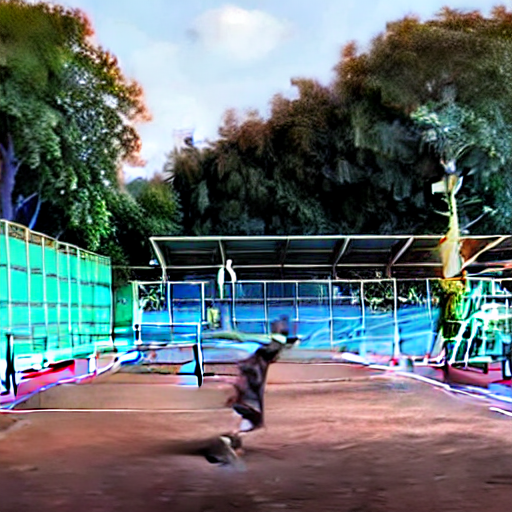

In [1]:
import torch
from pathlib import Path
from diffusers import StableDiffusionPipeline

WORKDIR = Path("/content/work").resolve()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

# Chargement du modèle de base
pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=DTYPE,
    safety_checker=None
).to(DEVICE)

# Chargement des poids LoRA
pipe.load_lora_weights(str(WORKDIR / "lora_output"), weight_name="last.safetensors")

# Génération
prompt = "sks tennis style a tennis player hitting a forehand shot"
image = pipe(prompt, num_inference_steps=25).images[0]
image.save(str(WORKDIR / "test_output.png"))
image

Étape 8 — Interface Gradio (Lien public Colab)


In [2]:
import gradio as gr
from diffusers import StableDiffusionPipeline
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=DTYPE, safety_checker=None
).to(DEVICE)
pipe.load_lora_weights(str(WORKDIR / "lora_output"), weight_name="last.safetensors")

def generate(prompt, negative_prompt, steps, guidance, lora_scale, seed):
    generator = torch.Generator(DEVICE).manual_seed(int(seed)) if seed >= 0 else None
    image = pipe(
        prompt,
        negative_prompt=negative_prompt or None,
        num_inference_steps=int(steps),
        guidance_scale=guidance,
        generator=generator,
        cross_attention_kwargs={"scale": lora_scale},
    ).images[0]
    return image

with gr.Blocks(title="Tennis LoRA Demo") as demo:
    gr.Markdown("## 🎾 Tennis Style LoRA Demo")
    with gr.Row():
        with gr.Column():
            prompt = gr.Textbox(label="Prompt", value="sks tennis style a tennis player hitting a forehand shot")
            negative_prompt = gr.Textbox(label="Negative prompt", value="blurry, distorted, extra limbs")
            steps = gr.Slider(5, 50, value=25, step=1, label="Inference steps")
            guidance = gr.Slider(1.0, 15.0, value=7.5, step=0.5, label="Guidance scale")
            lora_scale = gr.Slider(0.0, 1.5, value=1.0, step=0.05, label="LoRA strength")
            seed = gr.Number(value=-1, label="Seed (-1 = random)")
            btn = gr.Button("Generate", variant="primary")
        with gr.Column():
            output = gr.Image(label="Result")

    btn.click(generate, inputs=[prompt, negative_prompt, steps, guidance, lora_scale, seed], outputs=output)

demo.launch(share=True)  # share=True génère le lien d'accès public sur Colab

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://gi

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a25888d5a286044f6c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
